# 3. Machine Learning for Classification

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv'

# !wget $data -O data-week-3.csv

In [3]:
df = pd.read_csv('data-week-3.csv')
df.head()
len(df)

7043

In [4]:
base = df.columns
base = list(base)

In [5]:
print(base)

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [6]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

text_columns = list(df.select_dtypes(include=['object', 'string']).columns)
for c in text_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')

In [7]:
df.dtypes
'''
seniorcitizen is int64 - it is stored as 0/1 instead of yes/no. That's fine, we will treat it as a categorical variable later.
totalcharges is object - a string column - although it clearly contains numbers.
'''

"\nseniorcitizen is int64 - it is stored as 0/1 instead of yes/no. That's fine, we will treat it as a categorical variable later.\ntotalcharges is object - a string column - although it clearly contains numbers.\n"

In [8]:
# Our normalization step replaced spaces with underscores, so the missing values became "_", and pandas cannot parse that as a number
# We can force the conversion with errors='coerce'. Unparseable strings are then replaced with NaN
tc = pd.to_numeric(df.totalcharges, errors='coerce') 

In [9]:
tc.isnull().sum()

np.int64(11)

In [10]:
df[tc.isnull()][['customerid', 'totalcharges']]

,customerid,totalcharges
488,4472-lvygi,_
753,3115-czmzd,_
936,5709-lvoeq,_
1082,4367-nuyao,_
1340,1371-dwpaz,_
3331,7644-omvmy,_
3826,3213-vvolg,_
4380,2520-sgtta,_
5218,2923-arzlg,_
6670,4075-wkniu,_


In [11]:
df.totalcharges = pd.to_numeric(df.totalcharges, errors='coerce')
df.totalcharges = df.totalcharges.fillna(0)

In [12]:
df.churn.head()

0     no
1     no
2    yes
3     no
4    yes
Name: churn, dtype: str

## Setting up the validation framework

In [13]:
df['churn'] = (df['churn'] == 'yes').astype(int)

# 2. Ensuite seulement, on sépare les données
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['churn'])
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1, stratify=df_full_train['churn'])
len(df_train), len(df_val), len(df_test)

(4225, 1409, 1409)

In [14]:
df_val.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
6064,7568-podml,male,0,no,no,1,no,no_phone_service,dsl,no,...,no,no,yes,yes,month-to-month,yes,mailed_check,45.30,45.30,1
3862,5854-ksrbj,male,0,yes,yes,70,yes,yes,no,no_internet_service,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check,25.40,1782.05,0
2986,1303-srdok,female,0,yes,yes,55,yes,no,fiber_optic,no,...,no,no,no,no,two_year,yes,credit_card_(automatic),69.05,3842.60,0
2853,0233-fthav,female,0,no,no,60,yes,yes,fiber_optic,no,...,yes,no,no,no,one_year,yes,bank_transfer_(automatic),79.20,4765.00,0
1457,6362-qhafm,male,0,yes,no,42,yes,yes,fiber_optic,no,...,yes,yes,yes,yes,one_year,yes,electronic_check,108.30,4586.15,0


In [15]:
df_train = df_train.reset_index(drop=True) #drop=True argument discards the old index instead of adding it back as a column
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

#### Isolating the target

In [16]:
y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

In [17]:
del df_train['churn']
del df_val['churn']
del df_test['churn']

### EDA

#### reset train and validation index

In [18]:
df_full_train = df_full_train.reset_index(drop=True)

#### Missing values

In [19]:
df_full_train.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

#### Looking at the target: the churn rate

In [20]:
df_full_train.churn.value_counts(normalize=True)

churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

In [21]:
df_full_train.churn.value_counts()

churn
0    4139
1    1495
Name: count, dtype: int64

In [22]:
df_full_train.churn.mean()

np.float64(0.2653532126375577)

#### Numerical and categorical variables

In [23]:
numerical = ['tenure', 'monthlycharges', 'totalcharges']

categorical = [
    'gender',
    'seniorcitizen',
    'partner',
    'dependents',
    'phoneservice',
    'multiplelines',
    'internetservice',
    'onlinesecurity',
    'onlinebackup',
    'deviceprotection',
    'techsupport',
    'streamingtv',
    'streamingmovies',
    'contract',
    'paperlessbilling',
    'paymentmethod',
]

In [24]:
df_full_train[categorical].nunique()

gender              2
seniorcitizen       2
partner             2
dependents          2
phoneservice        2
multiplelines       3
internetservice     3
onlinesecurity      3
onlinebackup        3
deviceprotection    3
techsupport         3
streamingtv         3
streamingmovies     3
contract            3
paperlessbilling    2
paymentmethod       4
dtype: int64

#### Churn rate per group

In [25]:
global_churn = df_full_train.churn.mean()

In [26]:
churn_female = df_full_train[df_full_train.gender == 'female'].churn.mean()
churn_male = df_full_train[df_full_train.gender == 'male'].churn.mean()


In [27]:
churn_female, churn_male

(np.float64(0.26633345233845057), np.float64(0.2643840451817861))

In [28]:
global_churn - churn_female

np.float64(-0.0009802397008928931)

In [29]:
global_churn - churn_male

np.float64(0.0009691674557715801)

In [30]:
df_full_train.partner.value_counts()

partner
no     2905
yes    2729
Name: count, dtype: int64

In [31]:
churn_partner = df_full_train[df_full_train.partner == 'yes'].churn.mean()
churn_no_partner = df_full_train[df_full_train.partner == 'no'].churn.mean()
churn_partner, churn_no_partner

(np.float64(0.1989739831440088), np.float64(0.327710843373494))

In [32]:
global_churn - churn_partner, global_churn - churn_no_partner

(np.float64(0.06637922949354888), np.float64(-0.06235763073593631))

##### NOTE: global rate minus group rate - a positive difference means the group churns less than average, and a negative difference means it churns more. The larger the absolute difference, the more important the variable

### Risk ratio

In [33]:
'''
This is the risk ratio. It is easy to read:

risk = 1 means the group is as likely to churn as everyone else
risk > 1 means the group is more likely to churn
risk < 1 means the group is less likely to churn
Customers without a partner have a risk of 1.22 - they churn 22% more often than the average customer. Customers with a partner have a risk of 0.76 - they churn about 24% less often.
'''

'\nThis is the risk ratio. It is easy to read:\n\nrisk = 1 means the group is as likely to churn as everyone else\nrisk > 1 means the group is more likely to churn\nrisk < 1 means the group is less likely to churn\nCustomers without a partner have a risk of 1.22 - they churn 22% more often than the average customer. Customers with a partner have a risk of 0.76 - they churn about 24% less often.\n'

In [34]:
from IPython.display import display

for c in categorical:
    print(c)
    df_group = df_full_train.groupby(c).churn.agg(['mean', 'count'])
    df_group['diff'] = df_group['mean'] - global_churn
    df_group['risk'] = df_group['mean'] / global_churn
    display(df_group)
    print()
    print()


gender


,mean,count,diff,risk
gender,,,,
female,0.266333,2801,0.000980,1.003694
male,0.264384,2833,-0.000969,0.996348




seniorcitizen


,mean,count,diff,risk
seniorcitizen,,,,
0,0.236954,4714,-0.028399,0.892975
1,0.410870,920,0.145516,1.548387




partner


...

,mean,count,diff,risk
contract,,,,
month-to-month,0.427466,3102,0.162113,1.610933
one_year,0.110827,1173,-0.154526,0.417658
two_year,0.028698,1359,-0.236656,0.108149




paperlessbilling


,mean,count,diff,risk
paperlessbilling,,,,
no,0.160226,2303,-0.105127,0.603821
yes,0.338037,3331,0.072683,1.273912




paymentmethod


,mean,count,diff,risk
paymentmethod,,,,
bank_transfer_(automatic),0.161576,1244,-0.103778,0.608908
credit_card_(automatic),0.149217,1213,-0.116136,0.562333
electronic_check,0.457430,1891,0.192077,1.723853
mailed_check,0.192846,1286,-0.072507,0.726752


### Feature importance: Mutual information

In [35]:
from sklearn.metrics import mutual_info_score

In [36]:
mutual_info_score(df_full_train.churn, df_full_train.contract)

0.09885273922424297

In [37]:
mutual_info_score(df_full_train.gender, df_full_train.churn)

2.4366607815906605e-06

In [38]:
mutual_info_score(df_full_train.contract, df_full_train.churn)

0.09885273922424297

In [39]:
mutual_info_score(df_full_train.partner, df_full_train.churn)

0.010734595536181502

In [40]:
def mutual_info_churn_score(series):
    return mutual_info_score(series, df_full_train.churn)

In [41]:
mi = df_full_train[categorical].apply(mutual_info_churn_score)
mi.sort_values(ascending=False)

contract            0.098853
onlinesecurity      0.066099
techsupport         0.063823
internetservice     0.057011
onlinebackup        0.047476
paymentmethod       0.046861
deviceprotection    0.043627
streamingmovies     0.032325
streamingtv         0.032053
paperlessbilling    0.020481
dependents          0.015082
partner             0.010735
seniorcitizen       0.009871
multiplelines       0.000971
phoneservice        0.000164
gender              0.000002
dtype: float64

### Feature importance: Correlation

In [42]:
df_full_train.tenure.max()

np.int64(72)

In [43]:
# rank features by importance we don't care about the direction
df_full_train[numerical].corrwith(df_full_train.churn).abs()

tenure            0.345593
monthlycharges    0.198040
totalcharges      0.193761
dtype: float64

#### splitting customers into groups and computing the churn rate in each

In [44]:
# two months or less
df_full_train[df_full_train.tenure <= 2].churn.mean()

np.float64(0.5747800586510264)

In [45]:
# more than two months up to a year
df_full_train[(df_full_train.tenure > 2) & (df_full_train.tenure <= 12)].churn.mean()

np.float64(0.4075829383886256)

In [46]:
# longer than a year
df_full_train[df_full_train.tenure > 12].churn.mean()

np.float64(0.1726969463690018)

##### Remarque: Churn clearly decreases as tenure grows - exactly what the negative correlation told us

#### same check for monthly charges

In [47]:
df_full_train[df_full_train.monthlycharges <= 20].churn.mean()

np.float64(0.08285163776493257)

In [48]:
df_full_train[(df_full_train.monthlycharges > 20) & (df_full_train.monthlycharges <= 50)].churn.mean()

np.float64(0.18437025796661607)

In [49]:
df_full_train[df_full_train.monthlycharges > 50].churn.mean()

np.float64(0.31840927047669215)

##### Remarque: The more people pay monthly, the more likely they are to leave - the positive correlation confirmed

### One-hot encoding

In [50]:
from sklearn.feature_extraction import DictVectorizer

In [51]:
dv = DictVectorizer(sparse=False)

train_dict = df_train[numerical+categorical].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

In [52]:
dv.get_feature_names_out()

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'dependents=no', 'dependents=yes',
       'deviceprotection=no', 'deviceprotection=no_internet_service',
       'deviceprotection=yes', 'gender=female', 'gender=male',
       'internetservice=dsl', 'internetservice=fiber_optic',
       'internetservice=no', 'monthlycharges', 'multiplelines=no',
       'multiplelines=no_phone_service', 'multiplelines=yes',
       'onlinebackup=no', 'onlinebackup=no_internet_service',
       'onlinebackup=yes', 'onlinesecurity=no',
       'onlinesecurity=no_internet_service', 'onlinesecurity=yes',
       'paperlessbilling=no', 'paperlessbilling=yes', 'partner=no',
       'partner=yes', 'paymentmethod=bank_transfer_(automatic)',
       'paymentmethod=credit_card_(automatic)',
       'paymentmethod=electronic_check', 'paymentmethod=mailed_check',
       'phoneservice=no', 'phoneservice=yes', 'seniorcitizen',
       'streamingmovies=no', 'streamingmovies=no_internet_service',

In [53]:
X_train.shape

(4225, 45)

In [54]:
val_dict = df_val[numerical+categorical].to_dict(orient='records')
X_val = dv.transform(val_dict) # If we called fit again on validation, the columns could come out in a different order
#or a category that appears only in validation would create a new column. The matrix would no longer match the one the model was trained on.

### Logistic Regression

In [55]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

In [56]:
z = np.linspace(-7, 7, 51)

In [57]:
sigmoid(100000)

np.float64(1.0)

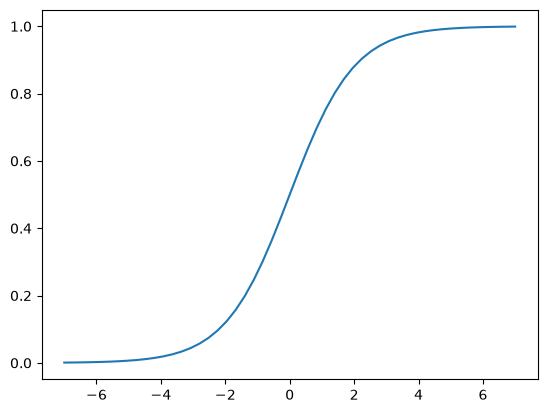

In [58]:
plt.plot(z, sigmoid(z))

In [59]:
def logistic_regression(xi):
    score = w0

    for j in range(len(w)):
        score = score + xi[j]*w[j]
    # apply the sigmoid function to the result of the LR to transform the value form a real value to a probability
    result = sigmoid(score)
    return result

### Training logistic Regression with Scikit-learn

In [60]:
from sklearn.linear_model import LogisticRegression

In [61]:
model = LogisticRegression(solver='liblinear', max_iter=1000)
model.fit(X_train, y_train)

,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalt

In [62]:
model.intercept_[0]

np.float64(-0.1831802999246838)

In [63]:
model.coef_[0].round(3)

array([ 0.639, -0.137, -0.685,  0.014, -0.197,  0.041, -0.144, -0.079,
       -0.085, -0.098, -0.403,  0.364, -0.144,  0.004, -0.231,  0.049,
       -0.001,  0.05 , -0.144, -0.089,  0.167, -0.144, -0.206, -0.257,
        0.074, -0.055, -0.129, -0.209, -0.184,  0.289, -0.079,  0.049,
       -0.232,  0.156, -0.126, -0.144,  0.088, -0.1  , -0.144,  0.061,
        0.173, -0.144, -0.211, -0.051,  0.   ])

In [64]:
y_pred = model.predict_proba(X_val)[:,1]

In [65]:
churn_decision = (y_pred>=0.5)

In [66]:
(y_val == churn_decision).mean()

np.float64(0.7814052519517388)

In [67]:
df_pred = pd.DataFrame()
df_pred['probability'] = y_pred
df_pred['prediction'] = churn_decision.astype(int)
df_pred['actual'] = y_val

In [68]:
df_pred['correct'] = df_pred.prediction == df_pred.actual
df_pred.correct.mean()

np.float64(0.7814052519517388)

In [69]:
churn_decision.astype(int)

array([1, 0, 0, ..., 1, 1, 1], shape=(1409,))

### Model interpretation

In [70]:
dict(zip(dv.get_feature_names_out(), model.coef_[0].round(3)))

{'contract=month-to-month': np.float64(0.639),
 'contract=one_year': np.float64(-0.137),
 'contract=two_year': np.float64(-0.685),
 'dependents=no': np.float64(0.014),
 'dependents=yes': np.float64(-0.197),
 'deviceprotection=no': np.float64(0.041),
 'deviceprotection=no_internet_service': np.float64(-0.144),
 'deviceprotection=yes': np.float64(-0.079),
 'gender=female': np.float64(-0.085),
 'gender=male': np.float64(-0.098),
 'internetservice=dsl': np.float64(-0.403),
 'internetservice=fiber_optic': np.float64(0.364),
 'internetservice=no': np.float64(-0.144),
 'monthlycharges': np.float64(0.004),
 'multiplelines=no': np.float64(-0.231),
 'multiplelines=no_phone_service': np.float64(0.049),
 'multiplelines=yes': np.float64(-0.001),
 'onlinebackup=no': np.float64(0.05),
 'onlinebackup=no_internet_service': np.float64(-0.144),
 'onlinebackup=yes': np.float64(-0.089),
 'onlinesecurity=no': np.float64(0.167),
 'onlinesecurity=no_internet_service': np.float64(-0.144),
 'onlinesecurity=yes'

In [71]:
small = ['contract', 'tenure', 'monthlycharges']

In [72]:
dicts_train_small = df_train[small].to_dict(orient='records')
dicts_val_small = df_val[small].to_dict(orient='records')

In [73]:
dv_small = DictVectorizer(sparse=False)
dv_small.fit(dicts_train_small)

DictVectorizer(sparse=False)

In [74]:
dv_small.get_feature_names_out()

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'monthlycharges', 'tenure'], dtype=object)

In [77]:
X_train_small = dv_small.transform(dicts_train_small)

In [80]:
model_small=LogisticRegression(solver='lbfgs')
model_small.fit(X_train_small, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

In [81]:
w0 = model_small.intercept_[0]

In [82]:
w0

np.float64(-2.7472374397109784)

In [84]:
w = model_small.coef_[0]
dict(zip(dv_small.get_feature_names_out(), w.round(3)))

{'contract=month-to-month': np.float64(1.066),
 'contract=one_year': np.float64(-0.075),
 'contract=two_year': np.float64(-0.993),
 'monthlycharges': np.float64(0.031),
 'tenure': np.float64(-0.037)}

### Scoring a customer by hand

##### With five numbers we can compute a prediction manually. Take a customer on a two-year contract, paying $30 per month, with 24 months of tenure. The score is the bias plus the weighted features 
##### only one of the three contract weights applies, because only one of them is 1

In [86]:
-2.747 + (-0.993) + 30 * 0.031 + 24 * (-0.037)

-3.6979999999999995

In [87]:
sigmoid(_)

np.float64(0.024174156078691094)

##### Only a 2.41% chance of churn - exactly what we would expect from a loyal customer on a two-year contract

### Using the model

In [89]:
dicts_full_train = df_full_train[numerical+categorical].to_dict(orient='records')

dv = DictVectorizer(sparse=False)
X_full_train = dv.fit_transform(dicts_full_train)

y_full_train = df_full_train.churn.values

In [92]:
model_full_train=LogisticRegression(solver='lbfgs', max_iter=10000)
model_full_train.fit(X_full_train, y_full_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",10000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use 

### Checking on the test set

In [96]:
dicts_test = df_test[numerical+categorical].to_dict(orient='records')
X_test=dv.transform(dicts_test)

y_pred = model.predict_proba(X_test)[:,1]
churn_decision = (y_pred>=0.5)

(churn_decision == y_test).mean()

np.float64(0.8026969481902059)

### Scoring one customer

In [97]:
customer = dicts_test[-1]
customer

{'tenure': 72,
 'monthlycharges': 70.45,
 'totalcharges': 5165.7,
 'gender': 'female',
 'seniorcitizen': 0,
 'partner': 'yes',
 'dependents': 'yes',
 'phoneservice': 'yes',
 'multiplelines': 'yes',
 'internetservice': 'dsl',
 'onlinesecurity': 'yes',
 'onlinebackup': 'yes',
 'deviceprotection': 'yes',
 'techsupport': 'yes',
 'streamingtv': 'no',
 'streamingmovies': 'no',
 'contract': 'two_year',
 'paperlessbilling': 'yes',
 'paymentmethod': 'bank_transfer_(automatic)'}

In [98]:
X_small = dv.transform([customer])
model.predict_proba(X_small)[0, 1]

np.float64(0.005901203501371445)

In [99]:
y_test[-1]

np.int64(0)